# 05 · Training a Small Network

**Goal:** put forward + backward + an optimiser together and train a real classifier from scratch with NumPy.

Training loop:
1. sample a mini-batch  →  2. forward  →  3. loss  →  4. backward  →  5. update $\theta\leftarrow\theta-\eta\,\nabla_\theta\mathcal L$

With momentum: $v\leftarrow\mu v-\eta g,\;\theta\leftarrow\theta+v$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy(P, Y):
    return -np.sum(Y * np.log(P + 1e-12)) / Y.shape[0]

## 1. A compact MLP class

In [2]:
class MLP:
    def __init__(self, sizes, seed=0):
        r = np.random.default_rng(seed)
        self.W = [r.normal(0, np.sqrt(2 / i), (i, o)) for i, o in zip(sizes[:-1], sizes[1:])]
        self.b = [np.zeros(o) for o in sizes[1:]]
        self.vW = [np.zeros_like(w) for w in self.W]      # momentum buffers
        self.vb = [np.zeros_like(b) for b in self.b]

    def forward(self, X):
        self.Z, self.A = [None], [X]
        L = len(self.W)
        for l in range(L):
            Z = self.A[-1] @ self.W[l] + self.b[l]
            self.Z.append(Z)
            self.A.append(softmax(Z) if l == L - 1 else np.maximum(0, Z))
        return self.A[-1]

    def backward(self, Y):
        N, L = Y.shape[0], len(self.W)
        gW, gb = [None] * L, [None] * L
        delta = (self.A[-1] - Y) / N
        for l in reversed(range(L)):
            gW[l] = self.A[l].T @ delta
            gb[l] = delta.sum(axis=0)
            if l > 0:
                delta = (delta @ self.W[l].T) * (self.Z[l] > 0)
        return gW, gb

    def step(self, gW, gb, lr, momentum=0.0):
        for l in range(len(self.W)):
            self.vW[l] = momentum * self.vW[l] - lr * gW[l]
            self.vb[l] = momentum * self.vb[l] - lr * gb[l]
            self.W[l] += self.vW[l]
            self.b[l] += self.vb[l]

    def predict(self, X):
        return self.forward(X).argmax(axis=1)

    def fit(self, X, Y, Xte, Yte, epochs=100, batch=32, lr=0.1, momentum=0.0, seed=0):
        r = np.random.default_rng(seed)
        hist = dict(loss=[], test_loss=[], train_acc=[], test_acc=[])
        for ep in range(epochs):
            idx = r.permutation(len(X))                     # shuffle every epoch
            for s in range(0, len(X), batch):
                j = idx[s:s + batch]
                self.forward(X[j])
                gW, gb = self.backward(Y[j])
                self.step(gW, gb, lr, momentum)
            Ptr, Pte = self.forward(X), self.forward(Xte)
            hist["loss"].append(cross_entropy(Ptr, Y))
            hist["test_loss"].append(cross_entropy(Pte, Yte))
            hist["train_acc"].append((Ptr.argmax(1) == Y.argmax(1)).mean())
            hist["test_acc"].append((Pte.argmax(1) == Yte.argmax(1)).mean())
        return hist

## 2. Warm-up: XOR – impossible for a single linear layer

In [3]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], float)
Y_xor = np.eye(2)[[0, 1, 1, 0]]

net = MLP([2, 8, 2], seed=1)
h = net.fit(X_xor, Y_xor, X_xor, Y_xor, epochs=2000, batch=4, lr=0.2, momentum=0.9)
print("XOR predictions:", net.predict(X_xor), "(target [0 1 1 0])   final loss:", round(h["loss"][-1], 5))

XOR predictions: [0 1 1 0] (target [0 1 1 0])   final loss: 0.00018


## 3. A harder dataset: 3-armed spiral

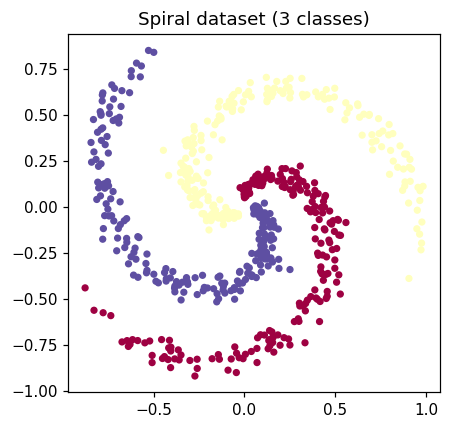

In [4]:
def make_spiral(n=200, k=3, noise=0.2, seed=0):
    r = np.random.default_rng(seed)
    X = np.zeros((n * k, 2)); y = np.zeros(n * k, dtype=int)
    for j in range(k):
        ix = slice(n * j, n * (j + 1))
        rad = np.linspace(0.05, 1.0, n)
        th = np.linspace(j * 4, (j + 1) * 4, n) + r.normal(0, noise, n)
        X[ix] = np.c_[rad * np.sin(th), rad * np.cos(th)]
        y[ix] = j
    return X, y

X, y = make_spiral()
perm = np.random.default_rng(0).permutation(len(X))
X, y = X[perm], y[perm]
n_tr = int(0.8 * len(X))
Xtr, ytr, Xte, yte = X[:n_tr], y[:n_tr], X[n_tr:], y[n_tr:]
Ytr, Yte = np.eye(3)[ytr], np.eye(3)[yte]

plt.figure(figsize=(4.2, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Spectral", s=14)
plt.title("Spiral dataset (3 classes)"); plt.tight_layout(); plt.show()

## 4. Train 2 → 64 → 64 → 3

final train acc = 1.000 | test acc = 1.000


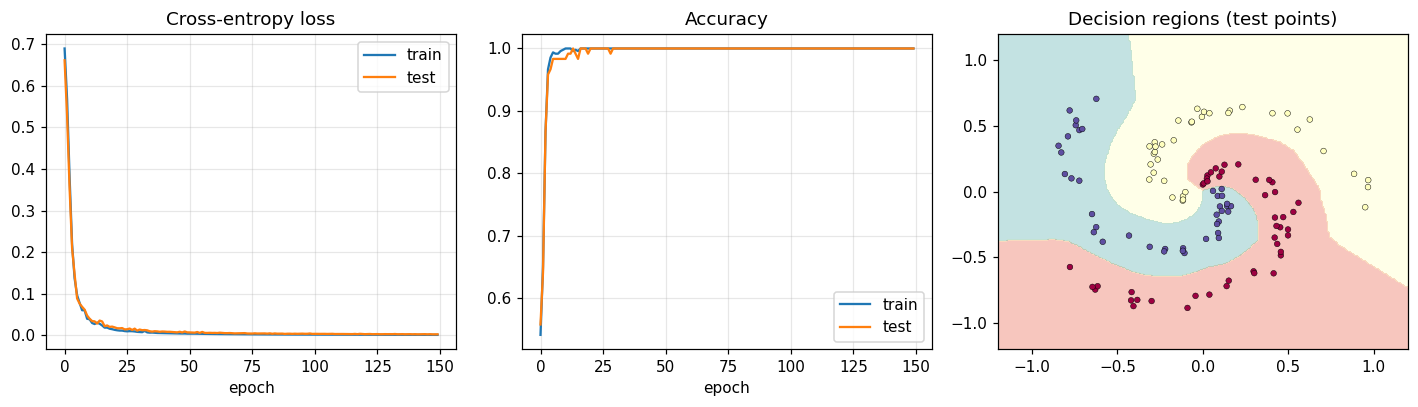

In [5]:
net = MLP([2, 64, 64, 3], seed=0)
hist = net.fit(Xtr, Ytr, Xte, Yte, epochs=150, batch=32, lr=0.05, momentum=0.9)
print(f"final train acc = {hist['train_acc'][-1]:.3f} | test acc = {hist['test_acc'][-1]:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].plot(hist["loss"], label="train"); ax[0].plot(hist["test_loss"], label="test")
ax[0].set_title("Cross-entropy loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(hist["train_acc"], label="train"); ax[1].plot(hist["test_acc"], label="test")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)

xx, yy = np.meshgrid(np.linspace(-1.2, 1.2, 300), np.linspace(-1.2, 1.2, 300))
zz = net.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax[2].contourf(xx, yy, zz, alpha=0.35, cmap="Spectral", levels=[-.5, .5, 1.5, 2.5])
ax[2].scatter(Xte[:, 0], Xte[:, 1], c=yte, cmap="Spectral", s=14, edgecolor="k", linewidth=.3)
ax[2].set_title("Decision regions (test points)")
plt.tight_layout(); plt.show()

## 5. The learning rate matters more than anything else

lr=0.001  final train loss = 0.8239   test acc = 0.525
lr=0.01   final train loss = 0.4815   test acc = 0.850
lr=0.1    final train loss = 0.0267   test acc = 0.992
lr=1.0    final train loss = 0.0012   test acc = 1.000
lr=5.0    final train loss = 1.1139   test acc = 0.325


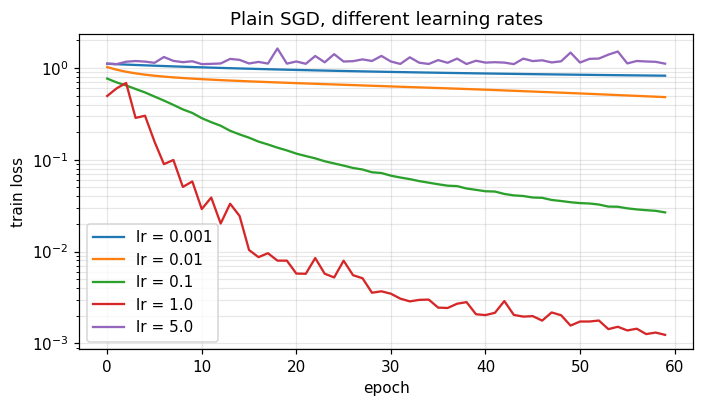

In [6]:
plt.figure(figsize=(6.5, 3.8))
for lr in (0.001, 0.01, 0.1, 1.0, 5.0):
    m = MLP([2, 64, 64, 3], seed=0)
    hh = m.fit(Xtr, Ytr, Xte, Yte, epochs=60, batch=32, lr=lr, momentum=0.0)
    plt.plot(hh["loss"], label=f"lr = {lr}")
    print(f"lr={lr:<6} final train loss = {hh['loss'][-1]:.4f}   test acc = {hh['test_acc'][-1]:.3f}")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("train loss")
plt.title("Plain SGD, different learning rates"); plt.legend(); plt.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

### Try it yourself
1. Compare `momentum=0` and `momentum=0.9` at the same learning rate.
2. Add an L2 penalty to `step` (weight decay) and see how the test-loss curve changes.
3. Replace ReLU by `tanh` (change both `forward` and `backward`) – does it still reach the same accuracy?
4. Swap the spiral for MNIST (`sklearn.datasets.load_digits` is a 64-feature mini version) with `sizes=[64, 64, 10]`.